### CG Pion quasi-DA: GPT v.s. PyQUDA

There are four methods for shift and contraction:
1. GPT: use g.slice and g.cshift
2. GPT: use g.slice_trDA and g.cshift
3. PyQUDA: use einsum contract and unit.pure_gauge.covDev
4. PyQUDA: use einsum contract and shift method

- PyQUDA + shift + 1 node:
    - Contraction time: 0.068 seconds
    - Shift time: 0.009 seconds
- PyQUDA + covDev + 1 node:
    - Contraction time: 0.068 seconds
    - Shift time: 1.058 seconds
- PyQUDA + shift + 2 nodes: 
    - Contraction time: 0.049 seconds
    - Shift time: 0.005 seconds
    - Loop time: ~ 18.5 seconds
- GPT + slice + 2 nodes:
    - Total contraction time: 0.15 ~ 0.20 seconds
    - Loop time: ~ 20 seconds
- GPT + slice_trDA + 2 nodes:
    - Total contraction time: 0.15 ~ 0.20 seconds
    - Loop time: ~ 19.4 seconds

There are few conclusions from the comparison:
- Three methods can give the exact same results of CG pion quasi-DA;
- PyQUDA only needs 1 node with 4 GPUs while GPT needs 2 nodes with 8 GPUs for the same measurement;
- Though the total contraction time of GPT is about 2 times slower than PyQUDA, the total loop time are quite close, probably because of the core.gatherLattice function;

In [1]:
import numpy as np
import gvar as gv

import matplotlib.pyplot as plt

from lametlat.utils.resampling import *
from lametlat.preprocess.read_raw import pt2_to_meff
from lametlat.utils.plot_settings import *
from lametlat.utils.constants import *

N_conf = 10  # Adjust based on your data
z_list = np.arange(8)

# Load the data
shift_path = f"dump/pion_DA_Nconf{N_conf}_shift.npz"
covdev_path = f"dump/pion_DA_Nconf{N_conf}_covDev.npz"
gpt_path = f"dump/pion_DA_Nconf{N_conf}_gpt.npz"

shift_data = np.load(shift_path, allow_pickle=True)    
shift_DA = shift_data["pion_DA"]
print(shift_DA.shape)

covdev_data = np.load(covdev_path, allow_pickle=True)
covdev_DA = covdev_data["pion_DA"]
print(covdev_DA.shape)

gpt_data = np.load(gpt_path, allow_pickle=True)
gpt_DA = gpt_data["pion_DA"]
print(gpt_DA.shape)

shift_da_jk = jackknife(shift_DA)
covdev_da_jk = jackknife(covdev_DA)
gpt_da_jk = jackknife(gpt_DA)

shift_da_jk_avg = jk_ls_avg(shift_da_jk)
covdev_da_jk_avg = jk_ls_avg(covdev_da_jk)
gpt_da_jk_avg = jk_ls_avg(gpt_da_jk)

(10, 8, 64)
(10, 8, 64)
(10, 8, 64)


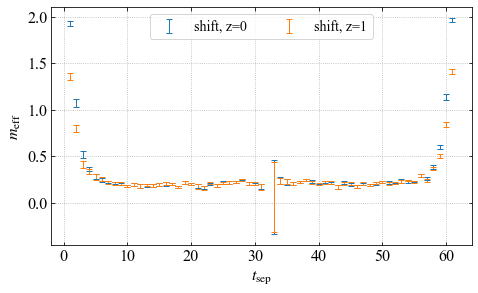

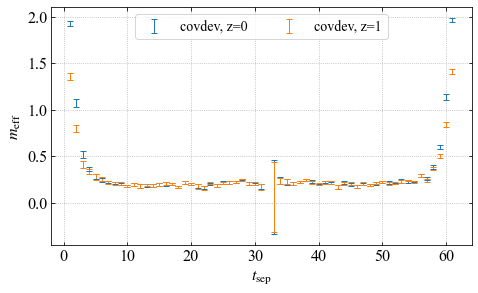

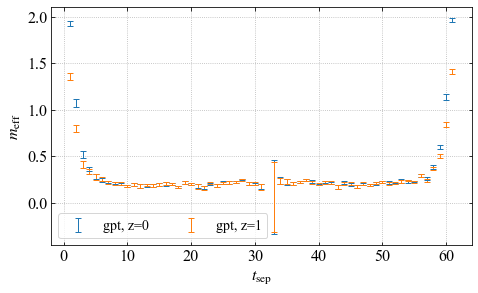

In [4]:
fig, ax = default_plot()
for idx, z in enumerate(z_list[:2]):
    shift_meff = pt2_to_meff(shift_da_jk_avg[idx], boundary="periodic")
    
    ax.errorbar(np.arange(len(shift_meff)), gv.mean(shift_meff), yerr=gv.sdev(shift_meff), label=f"shift, z={z}", **errorb)

ax.legend(ncol=2, **fs_small_p)
ax.set_xlabel(r"$t_{\mathrm{sep}}$", **fs_p)
ax.set_ylabel(r"$m_{\mathrm{eff}}$", **fs_p)
plt.tight_layout()
plt.show()

fig, ax = default_plot()
for idx, z in enumerate(z_list[:2]):
    covdev_meff = pt2_to_meff(covdev_da_jk_avg[idx], boundary="periodic")
    
    ax.errorbar(np.arange(len(covdev_meff)), gv.mean(covdev_meff), yerr=gv.sdev(covdev_meff), label=f"covdev, z={z}", **errorb)

ax.legend(ncol=2, **fs_small_p)
ax.set_xlabel(r"$t_{\mathrm{sep}}$", **fs_p)
ax.set_ylabel(r"$m_{\mathrm{eff}}$", **fs_p)
plt.tight_layout()
plt.show()

fig, ax = default_plot()
for idx, z in enumerate(z_list[:2]):
    gpt_meff = pt2_to_meff(gpt_da_jk_avg[idx], boundary="periodic")
    
    ax.errorbar(np.arange(len(gpt_meff)), gv.mean(gpt_meff), yerr=gv.sdev(gpt_meff), label=f"gpt, z={z}", **errorb)

ax.legend(ncol=2, **fs_small_p)
ax.set_xlabel(r"$t_{\mathrm{sep}}$", **fs_p)
ax.set_ylabel(r"$m_{\mathrm{eff}}$", **fs_p)
plt.tight_layout()
plt.show()

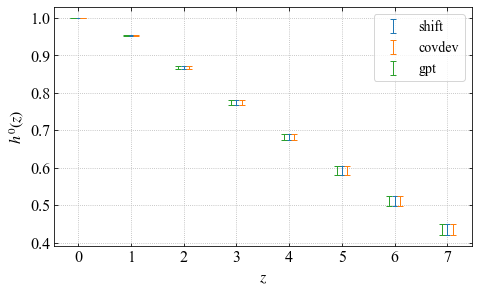

In [5]:
fix_t = 15
bare_shift_da = []
for z in z_list:
    bare_shift_da.append(shift_da_jk_avg[z][fix_t])
bare_shift_da = np.array(bare_shift_da)
bare_shift_da = bare_shift_da / bare_shift_da[0]

bare_covdev_da = []
for z in z_list:
    bare_covdev_da.append(covdev_da_jk_avg[z][fix_t])
bare_covdev_da = np.array(bare_covdev_da)
bare_covdev_da = bare_covdev_da / bare_covdev_da[0]

bare_gpt_da = []
for z in z_list:
    bare_gpt_da.append(gpt_da_jk_avg[z][fix_t])
bare_gpt_da = np.array(bare_gpt_da)
bare_gpt_da = bare_gpt_da / bare_gpt_da[0]

fig, ax = default_plot()
ax.errorbar(z_list, gv.mean(bare_shift_da), yerr=gv.sdev(bare_shift_da), label="shift", **errorb)
ax.errorbar(z_list+0.1, gv.mean(bare_covdev_da), yerr=gv.sdev(bare_covdev_da), label="covdev", **errorb)
ax.errorbar(z_list-0.1, gv.mean(bare_gpt_da), yerr=gv.sdev(bare_gpt_da), label="gpt", **errorb)

ax.legend(**fs_small_p)
ax.set_xlabel(r"$z$", **fs_p)
ax.set_ylabel(r"$h^0(z)$", **fs_p)
plt.tight_layout()
plt.show()